In [6]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski

print("RDKit is ready for MedAI")


RDKit is ready for MedAI


In [7]:
%pip install -q rdkit

Molecule: Aspirin
SMILES: CC(=O)Oc1ccccc1C(=O)O
----------------------------------------
Molecular Weight: 180.16 g/mol
LogP: 1.31
H-bond Donors: 1
H-bond Acceptors: 3
TPSA: 63.6 Å²
Rotatable Bonds: 2
Lipinski Violations: 0
Lipinski Screening Result: Pass


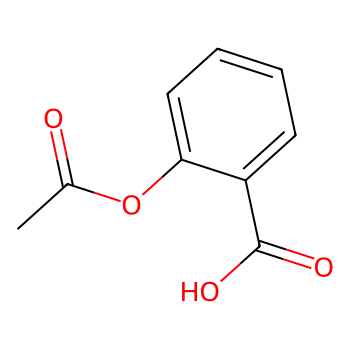

In [8]:
from rdkit.Chem import rdMolDescriptors, Draw

# Input molecule
molecule_name = "Aspirin"
smiles = "CC(=O)Oc1ccccc1C(=O)O"

# Convert SMILES into an RDKit molecule
mol = Chem.MolFromSmiles(smiles)

# Safety check
if mol is None:
    print("Invalid SMILES. Please check the molecular structure.")
else:
    # Molecular properties
    molecular_weight = round(Descriptors.MolWt(mol), 2)
    logp = round(Crippen.MolLogP(mol), 2)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    tpsa = round(rdMolDescriptors.CalcTPSA(mol), 2)
    rotatable_bonds = Lipinski.NumRotatableBonds(mol)

    # Lipinski Rule of Five checks
    lipinski_violations = sum([
        molecular_weight > 500,
        logp > 5,
        hbd > 5,
        hba > 10
    ])

    print(f"Molecule: {molecule_name}")
    print(f"SMILES: {smiles}")
    print("-" * 40)
    print(f"Molecular Weight: {molecular_weight} g/mol")
    print(f"LogP: {logp}")
    print(f"H-bond Donors: {hbd}")
    print(f"H-bond Acceptors: {hba}")
    print(f"TPSA: {tpsa} Å²")
    print(f"Rotatable Bonds: {rotatable_bonds}")
    print(f"Lipinski Violations: {lipinski_violations}")

    if lipinski_violations == 0:
        print("Lipinski Screening Result: Pass")
    else:
        print("Lipinski Screening Result: Flag for review")

    # Show 2D molecular structure
    display(Draw.MolToImage(mol, size=(350, 350)))

In [9]:
import pandas as pd

# Initial MedAI molecule set
molecules = [
    {"Molecule": "Aspirin", "SMILES": "CC(=O)Oc1ccccc1C(=O)O"},
    {"Molecule": "Paracetamol", "SMILES": "CC(=O)NC1=CC=C(O)C=C1"},
    {"Molecule": "Caffeine", "SMILES": "Cn1cnc2c1c(=O)n(C)c(=O)n2C"},
    {"Molecule": "Ibuprofen", "SMILES": "CC(C)Cc1ccc(cc1)C(C)C(=O)O"},
    {"Molecule": "Metformin", "SMILES": "CN(C)C(=N)NC(=N)N"}
]

def calculate_molecular_properties(molecule_name, smiles):
    mol = Chem.MolFromSmiles(smiles)

    # Invalid SMILES safety check
    if mol is None:
        return {
            "Molecule": molecule_name,
            "SMILES": smiles,
            "Status": "Invalid SMILES"
        }

    molecular_weight = round(Descriptors.MolWt(mol), 2)
    logp = round(Crippen.MolLogP(mol), 2)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    tpsa = round(rdMolDescriptors.CalcTPSA(mol), 2)
    rotatable_bonds = Lipinski.NumRotatableBonds(mol)

    lipinski_violations = sum([
        molecular_weight > 500,
        logp > 5,
        hbd > 5,
        hba > 10
    ])

    return {
        "Molecule": molecule_name,
        "SMILES": smiles,
        "Molecular_Weight": molecular_weight,
        "LogP": logp,
        "H_Bond_Donors": hbd,
        "H_Bond_Acceptors": hba,
        "TPSA": tpsa,
        "Rotatable_Bonds": rotatable_bonds,
        "Lipinski_Violations": lipinski_violations,
        "Lipinski_Status": "Pass" if lipinski_violations == 0 else "Flag for Review",
        "Status": "Valid"
    }

# Run analysis for every molecule
results = []

for item in molecules:
    result = calculate_molecular_properties(item["Molecule"], item["SMILES"])
    results.append(result)

# Convert results to DataFrame
df = pd.DataFrame(results)

# Show table
display(df)

# Save the table as a CSV file
csv_filename = "day01_molecular_properties.csv"
df.to_csv(csv_filename, index=False)

print(f"CSV created successfully: {csv_filename}")

,Molecule,SMILES,Molecular_Weight,LogP,H_Bond_Donors,H_Bond_Acceptors,TPSA,Rotatable_Bonds,Lipinski_Violations,Lipinski_Status,Status
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,180.16,1.31,1,3,63.60,2,0,Pass,Valid
1,Paracetamol,CC(=O)NC1=CC=C(O)C=C1,151.16,1.35,2,2,49.33,1,0,Pass,Valid
2,Caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,194.19,-1.03,0,3,61.82,0,0,Pass,Valid
3,Ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,206.28,3.07,1,1,37.30,4,0,Pass,Valid
4,Metformin,CN(C)C(=N)NC(=N)N,129.17,-1.03,4,2,88.99,0,0,Pass,Valid


CSV created successfully: day01_molecular_properties.csv


In [10]:
from google.colab import files

files.download("day01_molecular_properties.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>